#  PyTorch Computer Vision — FashionMNIST Classification (Corrected, Annotated & Extended)

 It builds and compares three image-classification models — a plain linear baseline, a linear model with non-linearity, and a Convolutional Neural Network (CNN) — on the [FashionMNIST](https://github.com/zalandoresearch/fashion-mnist) dataset (10 classes of clothing, 28×28 grayscale images), cross-checked against the **[official PyTorch documentation](https://docs.pytorch.org/docs/2.13/index.html)** (v2.13), **[learnpytorch.io's computer vision material](https://www.learnpytorch.io/02_pytorch_classification/)**, and **[TorchMetrics](https://lightning.ai/docs/torchmetrics/stable/)**. All explanations below are written fresh for this notebook — official docs/tutorials were only used to verify facts.

### What you'll find here
- 📝 A markdown explanation before **every** code cell
- 📚 Reference tables for the functions/classes used, right where they first appearix
- 📋 A cheat-sheet at the end for quick revision

### The computer vision workflow
```
0. Computer vision libraries in PyTorch
1. Load data
2. Prepare data (DataLoader / batches)
3. Model 0: a linear baseline
4. Making predictions and evaluating model 0
5. Device-agnostic code
6. Model 1: adding non-linearity
7. Model 2: a Convolutional Neural Network (CNN)
8. Model 3 (new): CNN + BatchNorm + Dropout + LR scheduler
9. Comparing all models
10. Evaluating the best model, and a full metrics report
11. Confusion matrix
12. Saving and loading the best model
```

> 💡 **Tip:** run top to bottom. Training here uses `epochs = 3` per model to keep runtime reasonable on CPU — bump it up if you have a GPU and want higher accuracy.

---
## 0. Computer vision libraries in PyTorch

| Module | What it does |
|---|---|
| `torchvision` | datasets, model architectures, and image transforms for computer vision |
| `torchvision.datasets` | ready-to-use CV datasets (and base classes for custom ones) |
| `torchvision.models` | well-known, commonly-used CV architectures (ResNet, VGG, ViT, ...) implemented in PyTorch |
| `torchvision.transforms` | common image transforms (resize, crop, normalize, augment, ...) |
| `torch.utils.data.Dataset` | base class for any PyTorch dataset (not CV-specific) |
| `torch.utils.data.DataLoader` | wraps a `Dataset` into a batched, iterable loader (not CV-specific) |

In [ ]:
# Import PyTorch
import torch
from torch import nn  # nn contains all of PyTorch's building blocks for neural networks

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor  # https://docs.pytorch.org/vision/main/generated/torchvision.transforms.ToTensor.html

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Check versions
# Note: PyTorch shouldn't be lower than 1.10.0, torchvision shouldn't be lower than 0.11
print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")

PyTorch version: 2.13.0+cu130
torchvision version: 0.28.0+cu130


---
## 1. Load the data

[FashionMNIST](https://github.com/zalandoresearch/fashion-mnist) is a drop-in replacement for the classic MNIST digits dataset: 70,000 28×28 grayscale images across 10 clothing categories (60,000 train / 10,000 test). `torchvision.datasets` ships it built-in, so no manual downloading is required.

| Parameter | What it does |
|---|---|
| `root` | where to store/look for the data on disk |
| `train` | `True` → training split, `False` → test split |
| `download` | download the data if it's not already at `root` |
| `transform` | applied to each image — `ToTensor()` converts a PIL image (`H, W, C`, values `0-255`) into a `float32` tensor (`C, H, W`, values `0.0-1.0`) |
| `target_transform` | same idea, but for labels |

In [ ]:
# Setup training data
train_data = datasets.FashionMNIST(
    root="data",              # where to download data to?
    train=True,                # get training data
    download=True,             # download data if it doesn't exist on disk
    transform=ToTensor(),      # images come as PIL, we want Torch tensors
    target_transform=None      # you can transform labels too, if needed
)

# Setup testing data
test_data = datasets.FashionMNIST(
    root="data",
    train=False,   # get test data
    download=True,
    transform=ToTensor()
)

## 1.1 Check the size of each split

In [ ]:
len(train_data), len(test_data)

(60000, 10000)

## 1.2 Look at a single sample

Each item is an `(image, label)` pair — the image is a tensor, the label is a plain `int`.

In [ ]:
# See first training sample
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [ ]:
# What's the shape of the image?
image.shape

torch.Size([1, 28, 28])

## 1.3 Class names and label mappings

| Attribute | What it holds |
|---|---|
| `.classes` | list of human-readable class names, indexed by label |
| `.class_to_idx` | dict mapping class name → integer label |
| `.targets` | tensor of every sample's integer label, in dataset order |

In [ ]:
# using .classes
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
# usage of .class_to_idx for a dictionary view
converted_to_idx = train_data.class_to_idx
converted_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [ ]:
# usage of .targets
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

## 1.4 Visualize a sample

`image.squeeze()` drops the size-1 color-channel dimension (`[1, 28, 28] → [28, 28]`) so `plt.imshow` can display it as a 2-D image.

Image shape: torch.Size([1, 28, 28])


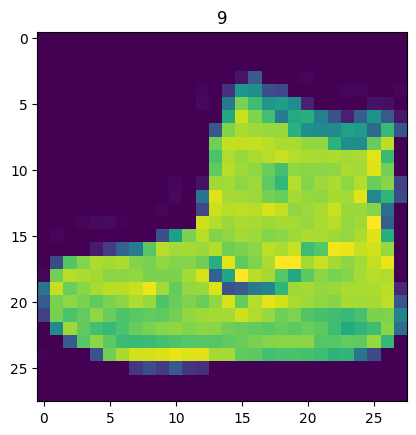

In [ ]:
image, label = train_data[0]
print(f"Image shape: {image.shape}")
# matplotlib expects a 2D array for grayscale display
plt.imshow(image.squeeze())  # image shape is [1, 28, 28] (colour_channels, height, width)
plt.title(label);

# note: a value of 0 renders as black by default

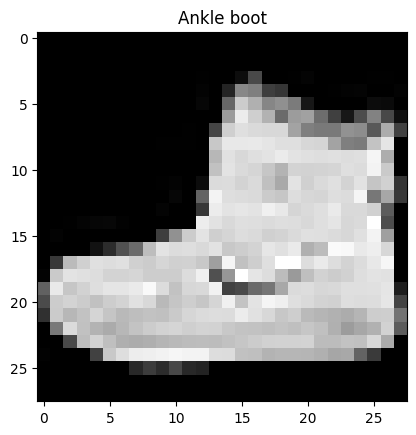

In [ ]:
# Turn the image into proper grayscale using the cmap parameter of plt.imshow()
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label]);

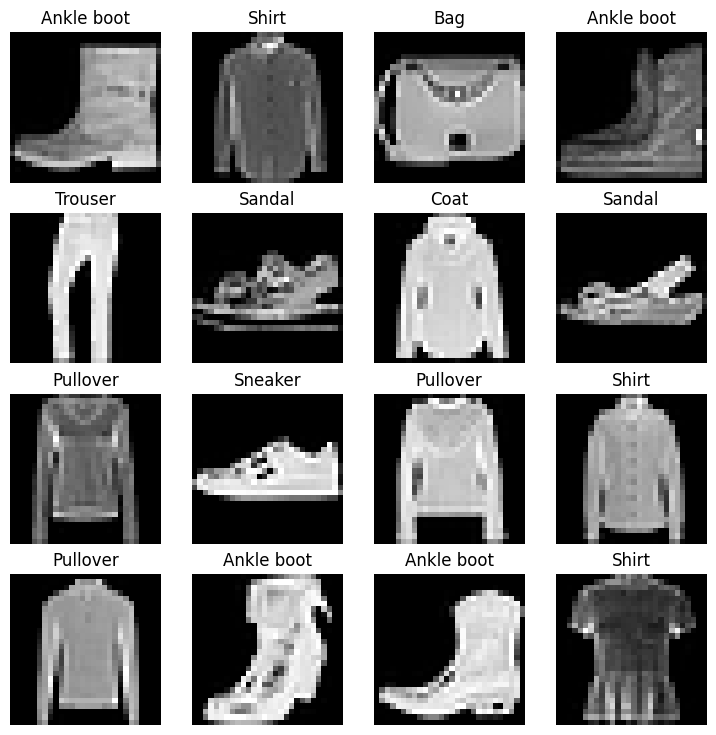

In [ ]:
# Plot a grid of random samples
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False);

---
## 2. Prepare the data — turn it into batches

A `DataLoader` wraps a `Dataset` into an iterable of **mini-batches**. Training on batches instead of the whole dataset (or one sample at a time) is more memory-efficient and gives the optimizer far more gradient-update opportunities per epoch (one update per batch, not one per epoch).

| Parameter | What it does |
|---|---|
| `dataset` | the `Dataset` to iterate over |
| `batch_size` | how many samples per batch (a common hyperparameter to tune) |
| `shuffle` | reshuffle the data every epoch — `True` for training (avoids the model memorizing sample order), usually `False` for testing (order doesn't matter, and keeping it fixed makes evaluation reproducible) |

In [ ]:
from torch.utils.data import DataLoader

# Setup the batch size hyperparameter
BATCH_SIZE = 32

# Turn datasets into iterables (batches)
train_dataloader = DataLoader(train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)
test_dataloader = DataLoader(test_data,
    batch_size=BATCH_SIZE,
    shuffle=False  # no need to shuffle test data
)

print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7efb146b50a0>, <torch.utils.data.dataloader.DataLoader object at 0x7efb14a28e60>)
Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


## 2.1 Inspect one batch

In [ ]:
# Check out what's inside the training dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size: torch.Size([1, 28, 28])
Label: 9, label size: torch.Size([])


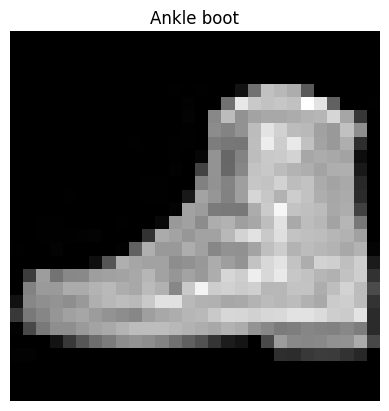

In [ ]:
# Show a sample from the batch
torch.manual_seed(49)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis("off");
print(f"Image size: {img.shape}")
print(f"Label: {label}, label size: {label.shape}")

---
## 3. Model 0 — a linear baseline

A **baseline** is the simplest reasonable model you can build — you try to beat it with subsequent experiments. Starting simple and adding complexity only when needed is good practice; it gives you a reference point for "is this improvement actually helping?"

`nn.Linear` layers expect a flat feature vector as input, but our images are `[1, 28, 28]` (channels, height, width). `nn.Flatten()` reshapes `[color_channels, height, width]` → `[color_channels, height × width]` (`1, 784`) so it can feed into a `Linear` layer.

| Class | What it does |
|---|---|
| `nn.Flatten()` | collapses all dimensions except the batch dimension into one — here, `[1, 28, 28] → [784]` |

In [ ]:
# Create a flatten layer
flatten_model = nn.Flatten()  # every nn.Module can do a forward pass

# Get a single sample
x = train_features_batch[0]

# Flatten the sample
output = flatten_model(x)

print(f"Shape before flattening: {x.shape} -> [color_channels, height, width]")
print(f"Shape after flattening: {output.shape} -> [color_channels, height*width]")

Shape before flattening: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Shape after flattening: torch.Size([1, 784]) -> [color_channels, height*width]


Now the full baseline model: `Flatten → Linear → Linear`. No non-linearity yet — that's deliberately saved for Model 1, so we can measure its effect in isolation.

In [ ]:
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)

In [ ]:
torch.manual_seed(42)

# Need to setup model with input parameters
model_0 = FashionMNISTModelV0(
    input_shape=784,             # one for every pixel (28x28)
    hidden_units=10,             # how many units in the hidden layer
    output_shape=len(class_names)  # one for every class
)
model_0.to("cpu")  # keep model on CPU to begin with

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

---
## 4. Loss function, optimizer & an accuracy helper

For multi-class classification, `nn.CrossEntropyLoss` is the standard choice — same as in the binary/multi-class notebook, it expects raw logits.

Rather than hand-roll `accuracy_fn` again, this section pulls it from [`helper_functions.py`](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/helper_functions.py) — a small utility module from the learnpytorch.io course repo with common helpers (`accuracy_fn`, plotting functions, etc.), fetched once and cached locally.

| Function | What it does |
|---|---|
| `requests.get(url)` | downloads the raw content at `url` |
| `Path.is_file()` | checks whether a path points to an existing file — used here to avoid re-downloading |

In [ ]:
import requests
from pathlib import Path

# Download helper functions from the Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
    print("helper_functions.py already exists, skipping download")
else:
    print("Downloading helper_functions.py")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
    with open("helper_functions.py", "wb") as f:
        f.write(request.content)

helper_functions.py already exists, skipping download


In [ ]:
# Import the accuracy metric
from helper_functions import accuracy_fn
# (torchmetrics.Accuracy(task="multiclass", ...) would also work here -- see the notebook on
#  binary/multi-class classification for that approach)

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()  # a.k.a. "criterion" / "cost function"
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

A small helper to time training runs, so we can compare not just accuracy but **speed** across models later.

In [ ]:
from timeit import default_timer as timer

def print_train_time(start: float, end: float, device: torch.device = None):
    """Prints the difference between start and end time.

    Args:
        start (float): start time (timeit format).
        end (float): end time.
        device: device the computation ran on, for the printout.

    Returns:
        float: elapsed time in seconds.
    """
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

---
## 5. Train Model 0

This first pass uses an explicit, "manual" double loop (epochs → batches) so the training/testing mechanics are fully visible before we wrap them into reusable `train_step` / `test_step` functions in §7.

| Function | What it does |
|---|---|
| `tqdm(iterable)` | wraps an iterable with a live progress bar |

In [ ]:
from tqdm.auto import tqdm

torch.manual_seed(42)
train_time_start_on_cpu = timer()

epochs = 3  # kept small for reasonable runtime on CPU

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")
    ### Training
    train_loss = 0
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()
        # 1. Forward pass
        y_pred = model_0(X)
        # 2. Calculate loss (per batch)
        loss = loss_fn(y_pred, y)
        train_loss += loss  # accumulate loss per epoch
        # 3. Optimizer zero grad
        optimizer.zero_grad()
        # 4. Loss backward
        loss.backward()
        # 5. Optimizer step
        optimizer.step()

        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

    train_loss /= len(train_dataloader)  # average loss per batch, per epoch

    ### Testing
    test_loss, test_acc = 0, 0
    model_0.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            test_pred = model_0(X)
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))
        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)

    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(
    start=train_time_start_on_cpu,
    end=train_time_end_on_cpu,
    device=str(next(model_0.parameters()).device)
)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Looked at 0/60000 samples


Looked at 12800/60000 samples


Looked at 25600/60000 samples


...

Looked at 38400/60000 samples


Looked at 51200/60000 samples



100%|██████████| 3/3 [00:28<00:00,  9.55s/it]


100%|██████████| 3/3 [00:28<00:00,  9.56s/it]


Train loss: 0.45503 | Test loss: 0.47664, Test acc: 83.43%

Train time on cpu: 28.672 seconds


---
## 6. Evaluate Model 0

Rather than repeat that whole training/eval pattern by hand for every model, package the "evaluate on a dataloader" half into a reusable `eval_model` function. This is the **one, canonical** definition — every later model reuses it directly instead of redefining it.

In [ ]:
torch.manual_seed(42)

def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device = "cpu"):
    """Evaluates a given model on a given dataset.

    Args:
        model: a PyTorch model capable of making predictions on data_loader.
        data_loader: the target dataset to predict on.
        loss_fn: the loss function of the model.
        accuracy_fn: a function to compare predictions to truth labels.
        device: target device to compute on.

    Returns:
        dict: results of the model's predictions on data_loader.
    """
    loss, acc = 0, 0
    model.to(device)
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
        loss /= len(data_loader)
        acc /= len(data_loader)
    return {"model_name": model.__class__.__name__,  # only works if the model was built as a class
            "model_loss": loss.item(),
            "model_acc": acc}

# Calculate model_0 results on the test dataset
model_0_results = eval_model(model=model_0, data_loader=test_dataloader,
                              loss_fn=loss_fn, accuracy_fn=accuracy_fn, device="cpu")
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42651757188499}

---
## 7. Device-agnostic code

From here on, every model is trained wherever a GPU is available (falling back to CPU).

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

---
## 8. Model 1 — adding non-linearity

Same shape as Model 0 (`784 → 10 → 10`), but with `nn.ReLU()` between the layers.

> **🔧 Bug fixed:** the original also had a `ReLU()` *after the final output layer* (`Linear → ReLU → Linear → ReLU`). `nn.CrossEntropyLoss` needs raw, unbounded logits — a class the model is confident *isn't* the answer should be able to get a large **negative** logit. A trailing `ReLU` clips every negative logit to exactly `0`, throwing that signal away and making several classes indistinguishable to the loss function. Fixed by removing it, so non-linearity is used only *between* layers, which is where it belongs.

In [ ]:
class FashionMNISTModelV1(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
            # no trailing ReLU -- CrossEntropyLoss needs raw logits, which can be negative
        )

    def forward(self, x: torch.Tensor):
        return self.layer_stack(x)

In [ ]:
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(
    input_shape=784,
    hidden_units=10,
    output_shape=len(class_names)
)
model_1.to(device)
next(model_1.parameters()).device

device(type='cpu')

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

### 8.1 Reusable `train_step` / `test_step`

Packaging one epoch's worth of training and testing into functions makes every later training loop a 3-line call instead of ~20 lines repeated per model.


In [ ]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    """Runs one epoch of training."""
    train_loss, train_acc = 0, 0
    model.to(device)
    model.train()
    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)

        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")


def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    """Runs one epoch of evaluation."""
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            test_pred = model(X)
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

### 8.2 Train Model 1

In [ ]:
torch.manual_seed(42)
train_time_start_on_gpu = timer()

epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader=train_dataloader, model=model_1, loss_fn=loss_fn,
               optimizer=optimizer, accuracy_fn=accuracy_fn, device=device)
    test_step(data_loader=test_dataloader, model=model_1, loss_fn=loss_fn,
              accuracy_fn=accuracy_fn, device=device)

train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(
    start=train_time_start_on_gpu, end=train_time_end_on_gpu, device=device
)


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------


Train loss: 0.64607 | Train accuracy: 77.17%



 33%|███▎      | 1/3 [00:09<00:19,  9.67s/it]

Test loss: 0.53855 | Test accuracy: 80.76%

Epoch: 1
---------


...

Test loss: 0.49390 | Test accuracy: 82.46%

Epoch: 2
---------


Train loss: 0.44689 | Train accuracy: 84.16%



100%|██████████| 3/3 [00:29<00:00,  9.91s/it]


100%|██████████| 3/3 [00:29<00:00,  9.88s/it]

Test loss: 0.45746 | Test accuracy: 83.99%

Train time on cpu: 29.643 seconds


In [ ]:
# Calculate model_1 results (reusing the single eval_model defined in §6)
model_1_results = eval_model(model=model_1, data_loader=test_dataloader,
                              loss_fn=loss_fn, accuracy_fn=accuracy_fn, device=device)
model_1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.45746350288391113,
 'model_acc': 83.98562300319489}

---
## 9. Model 2 — a Convolutional Neural Network (CNN)

A CNN uses `nn.Conv2d` layers, which slide small learned filters across the image to detect local patterns (edges, textures, shapes) — this generally works far better for image data than flattening straight into `Linear` layers, because it preserves spatial structure instead of throwing it away immediately.

This model follows the classic **[TinyVGG](https://poloclub.github.io/cnn-explainer/)**-style pattern: two convolutional blocks (`Conv2d → ReLU → Conv2d → ReLU → MaxPool2d`), then a `classifier` that flattens and projects down to `len(class_names)` logits.

| Class | Signature | What it does |
|---|---|---|
| `nn.Conv2d` | `Conv2d(in_channels, out_channels, kernel_size, stride, padding)` | slides `out_channels` learned filters of size `kernel_size` across the input; see [PyTorch's `Conv2d` docs](https://docs.pytorch.org/docs/2.13/generated/torch.nn.Conv2d.html) for the exact output-size formula |
| `nn.MaxPool2d` | `MaxPool2d(kernel_size, stride, padding)` | downsamples by taking the max value in each `kernel_size` window — reduces spatial size and adds a little translation-invariance |

In [ ]:
class FashionMNISTModelV2(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()

        # First convolutional block
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units,
                       kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                       kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Second convolutional block
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                       kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                       kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # Classifier (fully connected layer)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 7 * 7,  # 28x28 -> 14x14 -> 7x7 after the two MaxPool2d layers
                       out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x

In [ ]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1, hidden_units=10, output_shape=len(class_names)).to(device)
model_2

FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

### 9.1 Sanity-checking `Conv2d` / `MaxPool2d` shapes with dummy data

Getting `in_features` right for a CNN's `classifier` (here, `hidden_units * 7 * 7`) is a very common source of shape-mismatch errors. Before trusting the number above, it's worth stepping through what `Conv2d` and `MaxPool2d` actually do to a tensor's shape, using throwaway random data that's easy to reason about.

In [ ]:
# Create dummy data shaped like a small batch of RGB images
torch.manual_seed(42)
images = torch.rand(size=(32, 3, 64, 64))  # [batch_size, color_channels, height, width]
test_image = images[0]
print(f"Single image shape: {test_image.shape}")
print(f"With a batch dimension added: {test_image.unsqueeze(dim=0).shape}")

Single image shape: torch.Size([3, 64, 64])
With a batch dimension added: torch.Size([1, 3, 64, 64])


In [ ]:
# A Conv2d layer expects a batch dimension -- unsqueeze(0) adds one for a single image
conv_layer_1 = nn.Conv2d(in_channels=3, out_channels=11, kernel_size=3, stride=1, padding=0)
conv_output = conv_layer_1(test_image.unsqueeze(0))
print(conv_output.shape)  # note: 11 in the output channel dim comes straight from out_channels above

torch.Size([1, 11, 62, 62])


In [ ]:
conv_layer_1 = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3, stride=1, padding=1)
conv_output = conv_layer_1(test_image.unsqueeze(0))
print(f"shape after conv layer (padding=1, so spatial size is preserved): {conv_output.shape}")

maxpool_layer = nn.MaxPool2d(kernel_size=2)
print(f"shape after maxpool layer (halves height & width): {maxpool_layer(conv_output).shape}")

shape after conv layer (padding=1, so spatial size is preserved): torch.Size([1, 10, 64, 64])
shape after maxpool layer (halves height & width): torch.Size([1, 10, 32, 32])


Now confirm `model_2` itself produces the expected output shape (`[batch, num_classes]`) on a single dummy FashionMNIST-shaped image:

In [ ]:
torch.manual_seed(42)
rand_test_tensor = torch.randn(size=(1, 28, 28))
model_2(rand_test_tensor.unsqueeze(dim=0).to(device))

tensor([[ 0.0448, -0.0821,  0.0899, -0.0486,  0.0080,  0.0345,  0.0050,  0.0015,
         -0.0139, -0.0116]], grad_fn=<AddmmBackward0>)

### 9.2 Train and evaluate Model 2

Reusing the exact same `loss_fn` pattern, `train_step`/`test_step`, and `eval_model` from §8 — no redefinitions needed.

In [ ]:
torch.manual_seed(42)
rand_test_tensor = torch.randn(size=(1, 28, 28))
model_2(rand_test_tensor.unsqueeze(dim=0).to(device))

In [ ]:
torch.manual_seed(42)
train_time_start_model_2 = timer()

epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(model=model_2, data_loader=train_dataloader, loss_fn=loss_fn,
               optimizer=optimizer, accuracy_fn=accuracy_fn, device=device)
    test_step(model=model_2, data_loader=test_dataloader, loss_fn=loss_fn,
              accuracy_fn=accuracy_fn, device=device)

train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(
    start=train_time_start_model_2, end=train_time_end_model_2, device=device
)


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------


Train loss: 0.59604 | Train accuracy: 78.33%



 33%|███▎      | 1/3 [00:40<01:21, 40.57s/it]

Test loss: 0.40950 | Test accuracy: 85.16%

Epoch: 1
---------


...

Test loss: 0.35349 | Test accuracy: 86.72%

Epoch: 2
---------


Train loss: 0.33665 | Train accuracy: 87.69%



100%|██████████| 3/3 [02:07<00:00, 42.89s/it]


100%|██████████| 3/3 [02:07<00:00, 42.34s/it]

Test loss: 0.33410 | Test accuracy: 88.00%

Train time on cpu: 127.025 seconds


In [ ]:
model_2_results = eval_model(model=model_2, data_loader=test_dataloader,
                              loss_fn=loss_fn, accuracy_fn=accuracy_fn, device=device)
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.33409684896469116,
 'model_acc': 87.99920127795527}

---
## 10. 🧪 Model 3: CNN + BatchNorm + Dropout + a learning-rate scheduler

| Technique | PyTorch class | What it does |
|---|---|---|
| Batch normalization | [`nn.BatchNorm2d`](https://docs.pytorch.org/docs/2.13/generated/torch.nn.BatchNorm2d.html) | normalizes each mini-batch's activations to zero mean / unit variance (per channel), which generally speeds up and stabilizes training |
| Dropout | [`nn.Dropout`](https://docs.pytorch.org/docs/2.13/generated/torch.nn.Dropout.html) | randomly zeroes a fraction of activations during training only, which discourages the network from over-relying on any single unit (a regularizer against overfitting) |
| LR scheduling | [`torch.optim.lr_scheduler.OneCycleLR`](https://docs.pytorch.org/docs/2.13/generated/torch.optim.lr_scheduler.OneCycleLR.html) | varies the learning rate across training instead of holding it fixed — ramping up then annealing down, which often converges faster and to a better optimum than a constant LR |

Same two-conv-block-plus-classifier shape as Model 2, with `BatchNorm2d` after every `Conv2d` and `Dropout` before the final classifier layer.

In [ ]:
class FashionMNISTModelV3(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int, dropout: float = 0.3):
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units,
                       kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                       kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                       kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                       kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=dropout),
            nn.Linear(in_features=hidden_units * 7 * 7, out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x

torch.manual_seed(42)
model_3 = FashionMNISTModelV3(input_shape=1, hidden_units=10, output_shape=len(class_names)).to(device)
model_3

FashionMNISTModelV3(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, c

`OneCycleLR` needs to know the total number of optimizer steps up front (`epochs * steps_per_epoch`), so it can plan the ramp-up/anneal-down schedule. Note this uses `Adam` rather than `SGD` — pairing `OneCycleLR` with `Adam` is a common, well-documented combination for faster convergence.

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_3.parameters(), lr=0.01)

epochs = 3
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.01,
    steps_per_epoch=len(train_dataloader),
    epochs=epochs
)

`train_step` from §8 doesn't step a scheduler, so Model 3 gets its own small training loop that does — everything else (forward pass, loss, backward, optimizer step) is identical to `train_step` / `test_step`, which are still reused for the evaluation half.

In [ ]:
def train_step_with_scheduler(model, data_loader, loss_fn, optimizer, scheduler, accuracy_fn, device):
    train_loss, train_acc = 0, 0
    model.to(device)
    model.train()
    for X, y in data_loader:
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()  # OneCycleLR updates every batch, not every epoch

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

torch.manual_seed(42)
train_time_start_model_3 = timer()

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step_with_scheduler(model=model_3, data_loader=train_dataloader, loss_fn=loss_fn,
                               optimizer=optimizer, scheduler=scheduler, accuracy_fn=accuracy_fn, device=device)
    test_step(model=model_3, data_loader=test_dataloader, loss_fn=loss_fn,
              accuracy_fn=accuracy_fn, device=device)

train_time_end_model_3 = timer()
total_train_time_model_3 = print_train_time(
    start=train_time_start_model_3, end=train_time_end_model_3, device=device
)


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------


Train loss: 0.55696 | Train accuracy: 79.84%



 33%|███▎      | 1/3 [00:52<01:45, 52.82s/it]

Test loss: 0.36374 | Test accuracy: 86.74%

Epoch: 1
---------


...

Test loss: 0.30861 | Test accuracy: 88.88%

Epoch: 2
---------


Train loss: 0.28949 | Train accuracy: 89.52%



100%|██████████| 3/3 [02:35<00:00, 51.63s/it]


100%|██████████| 3/3 [02:35<00:00, 51.85s/it]

Test loss: 0.27166 | Test accuracy: 90.24%

Train time on cpu: 155.559 seconds


In [ ]:
model_3_results = eval_model(model=model_3, data_loader=test_dataloader,
                              loss_fn=loss_fn, accuracy_fn=accuracy_fn, device=device)
model_3_results

{'model_name': 'FashionMNISTModelV3',
 'model_loss': 0.27165552973747253,
 'model_acc': 90.23562300319489}

---
## 11. Comparing all four models

| Function | What it does |
|---|---|
| `pd.DataFrame(list_of_dicts)` | builds a table where each dict becomes a row |
| `df.set_index(col)` | uses a column as the row labels instead of the default `0, 1, 2, ...` |
| `df.plot(kind="barh")` | horizontal bar chart straight from a DataFrame/Series |

In [ ]:
import pandas as pd

compare_results = pd.DataFrame([
    model_0_results,
    model_1_results,
    model_2_results,
    model_3_results
])
compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,0.476639,83.426518
1,FashionMNISTModelV1,0.457464,83.985623
2,FashionMNISTModelV2,0.334097,87.999201
3,FashionMNISTModelV3,0.271656,90.235623


In [ ]:
compare_results["training_time_sec"] = [
    total_train_time_model_0,
    total_train_time_model_1,
    total_train_time_model_2,
    total_train_time_model_3
]
compare_results

,model_name,model_loss,model_acc,training_time_sec
0,FashionMNISTModelV0,0.476639,83.426518,28.672204
1,FashionMNISTModelV1,0.457464,83.985623,29.643322
2,FashionMNISTModelV2,0.334097,87.999201,127.025234
3,FashionMNISTModelV3,0.271656,90.235623,155.559139


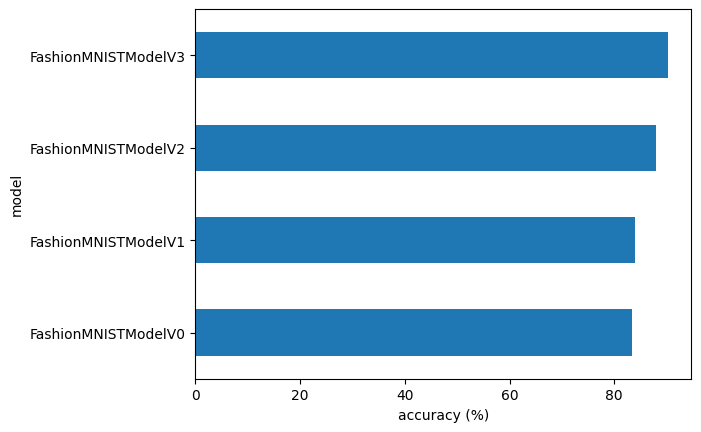

In [ ]:
# Visualize accuracy vs. model
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model");

Accuracy alone doesn't tell the whole story — plotting accuracy against training time shows the classic **accuracy vs. speed trade-off** between the plain linear models and the (slower, but more accurate) CNNs:

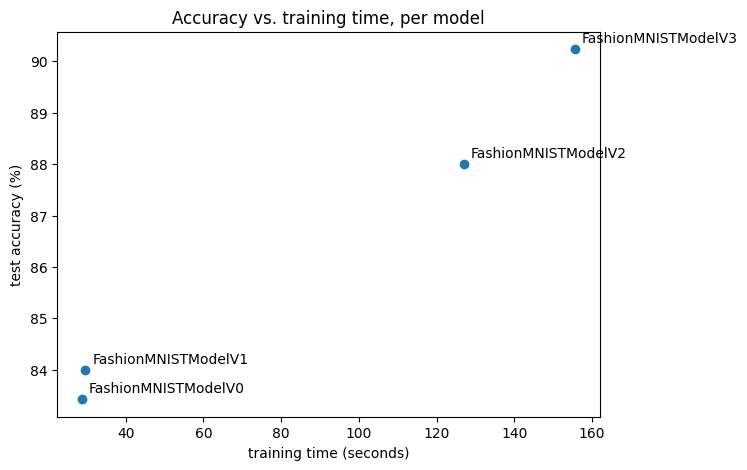

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(compare_results["training_time_sec"], compare_results["model_acc"])
for _, row in compare_results.iterrows():
    ax.annotate(row["model_name"], (row["training_time_sec"], row["model_acc"]),
                textcoords="offset points", xytext=(5, 5))
ax.set_xlabel("training time (seconds)")
ax.set_ylabel("test accuracy (%)")
ax.set_title("Accuracy vs. training time, per model");

---
## 12. Making predictions with the best model

| Function | What it does |
|---|---|
| `torch.unsqueeze(x, dim)` | adds a size-1 dimension — here, turns a single image `[C,H,W]` into a "batch of 1" `[1,C,H,W]`, since the model expects a batch dimension |
| `torch.stack(list_of_tensors)` | stacks a list of tensors along a new dimension into one tensor |

In [ ]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            sample = torch.unsqueeze(sample, dim=0).to(device)  # add batch dim, move to device
            pred_logit = model(sample)  # raw logits
            # softmax across the class dimension (dim=0, since batch size here is 1 -> squeezed away)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)
            pred_probs.append(pred_prob.cpu())
    return torch.stack(pred_probs)

In [ ]:
import random
random.seed(42)
test_samples, test_labels = [], []
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({class_names[test_labels[0]]})")

Test sample image shape: torch.Size([1, 28, 28])
Test sample label: 5 (Sandal)


In [ ]:
# Make predictions on the 9 test samples with model_3 (our best-performing model, per §11)
pred_probs = make_predictions(model=model_3, data=test_samples)
pred_probs[:2]

tensor([[1.0980e-07, 1.4493e-10, 5.5443e-10, 3.6123e-11, 2.3285e-10, 1.0000e+00,
         8.1835e-09, 4.6065e-10, 6.2778e-07, 1.9724e-06],
        [3.3768e-03, 9.9344e-01, 7.0825e-05, 2.0194e-03, 3.1181e-04, 4.5046e-07,
         5.6059e-04, 3.4614e-06, 2.1345e-04, 3.5123e-06]])

In [ ]:
# Turn prediction probabilities into prediction labels
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([5, 1, 7, 4, 3, 0, 4, 7, 1])

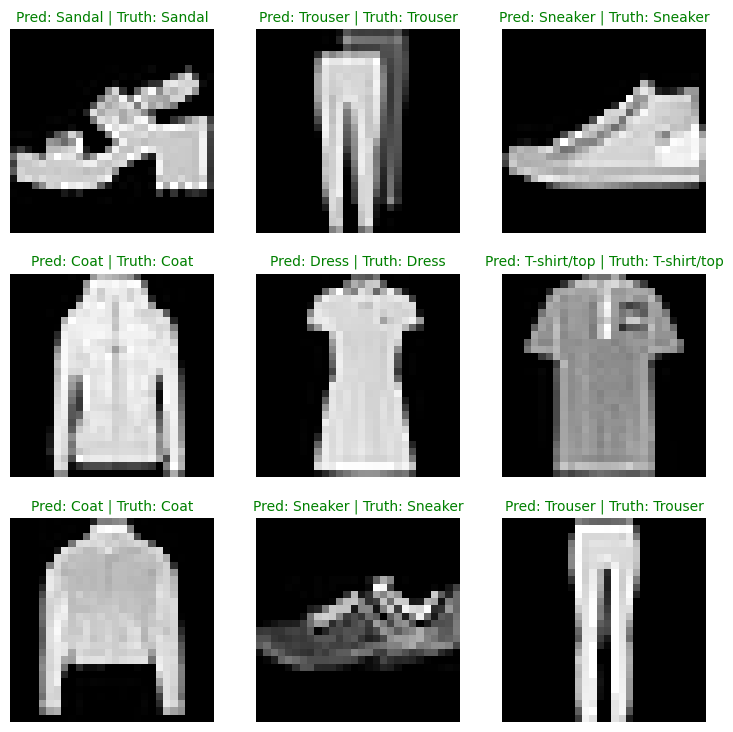

In [ ]:
plt.figure(figsize=(9, 9))
nrows, ncols = 3, 3
for i, sample in enumerate(test_samples):
    plt.subplot(nrows, ncols, i + 1)
    plt.imshow(sample.squeeze(), cmap="gray")

    pred_label = class_names[pred_classes[i]]
    truth_label = class_names[test_labels[i]]
    title_text = f"Pred: {pred_label} | Truth: {truth_label}"

    plt.title(title_text, fontsize=10, c="g" if pred_label == truth_label else "r")
    plt.axis(False);

---
## 13. Predictions on the entire test set

Needed for both the confusion matrix (§14) and the per-class metrics (§15) below.

In [ ]:
y_preds = []
model_3.eval()
with torch.inference_mode():
    for X, y in tqdm(test_dataloader, desc="Making predictions"):
        X, y = X.to(device), y.to(device)
        y_logit = model_3(X)
        y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1)  # softmax across classes (dim=1 for a batch)
        y_preds.append(y_pred.cpu())

y_pred_tensor = torch.cat(y_preds)


Making predictions:   0%|          | 0/313 [00:00<?, ?it/s]


Making predictions:   4%|▎         | 11/313 [00:00<00:02, 104.77it/s]


Making predictions:   7%|▋         | 22/313 [00:00<00:02, 103.56it/s]


Making predictions:  11%|█         | 33/313 [00:00<00:02, 102.39it/s]


Making predictions:  14%|█▍        | 44/313 [00:00<00:02, 101.10it/s]

...


Making predictions:  88%|████████▊ | 274/313 [00:02<00:00, 105.68it/s]


Making predictions:  91%|█████████ | 285/313 [00:02<00:00, 104.69it/s]


Making predictions:  95%|█████████▍| 296/313 [00:02<00:00, 104.84it/s]


Making predictions:  98%|█████████▊| 307/313 [00:02<00:00, 104.26it/s]


Making predictions: 100%|██████████| 313/313 [00:03<00:00, 103.56it/s]

---
## 14. Confusion matrix


| Function | Signature | What it does |
|---|---|---|
| `torchmetrics.ConfusionMatrix` | `ConfusionMatrix(task, num_classes)` | computes a predicted-vs-true count matrix |
| `mlxtend.plotting.plot_confusion_matrix` | `plot_confusion_matrix(conf_mat, class_names, figsize)` | renders a `torchmetrics`/`sklearn`-style confusion matrix as a matplotlib figure with class labels |

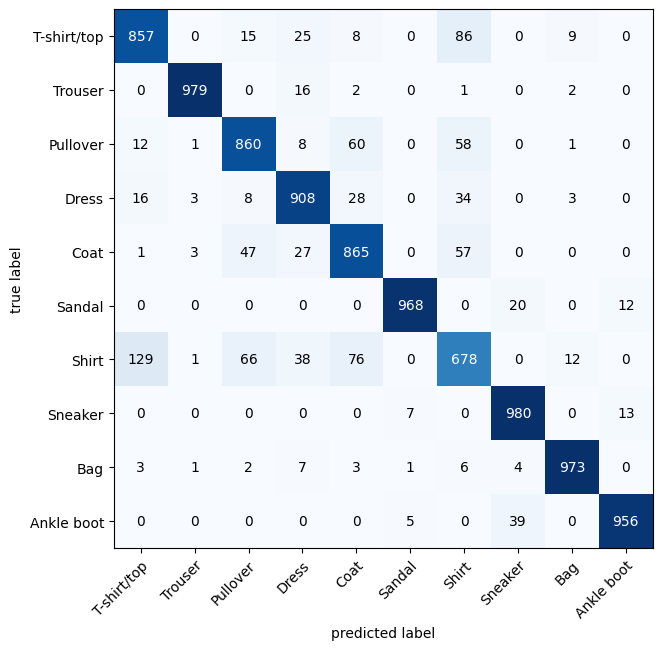

In [ ]:
try:
    from torchmetrics import ConfusionMatrix
except ImportError:
    !pip install -q torchmetrics  # task= requires torchmetrics >= 0.11

try:
    import mlxtend
    assert int(mlxtend.__version__.split(".")[1]) >= 19
except (ImportError, AssertionError):
    !pip install -q -U mlxtend  # need >= 0.19.0 for plot_confusion_matrix's current signature

from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# 1. Setup confusion matrix instance and compare predictions to targets
confmat = ConfusionMatrix(task="multiclass", num_classes=len(class_names))
confmat_tensor = confmat(preds=y_pred_tensor, target=test_data.targets)

# 2. Plot the confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),  # matplotlib likes working with NumPy
    class_names=class_names,
    figsize=(10, 7)
);

---
## 15. 🧪 per-class precision, recall & F1


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    test_data.targets.numpy(),
    y_pred_tensor.numpy(),
    target_names=class_names
))

              precision    recall  f1-score   support

 T-shirt/top       0.84      0.86      0.85      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.86      0.86      0.86      1000
       Dress       0.88      0.91      0.90      1000
        Coat       0.83      0.86      0.85      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.74      0.68      0.71      1000
     Sneaker       0.94      0.98      0.96      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.97      0.96      0.97      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



And the same metrics computed with `torchmetrics` (macro-averaged into single numbers, handy for quickly comparing model checkpoints):

In [ ]:
from torchmetrics import Precision, Recall, F1Score, Accuracy

num_classes = len(class_names)
accuracy_metric = Accuracy(task="multiclass", num_classes=num_classes, average="macro")
precision_metric = Precision(task="multiclass", num_classes=num_classes, average="macro")
recall_metric = Recall(task="multiclass", num_classes=num_classes, average="macro")
f1_metric = F1Score(task="multiclass", num_classes=num_classes, average="macro")

print(f"Accuracy:  {accuracy_metric(y_pred_tensor, test_data.targets) * 100:.2f}%")
print(f"Precision: {precision_metric(y_pred_tensor, test_data.targets):.4f}")
print(f"Recall:    {recall_metric(y_pred_tensor, test_data.targets):.4f}")
print(f"F1-score:  {f1_metric(y_pred_tensor, test_data.targets):.4f}")

Accuracy:  90.24%
Precision: 0.9018
Recall:    0.9024
F1-score:  0.9018


---
## 16. Saving and loading the best model

In [ ]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "03_pytorch_computer_vision_model_3.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_3.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models/03_pytorch_computer_vision_model_3.pth


In [ ]:
# Create a new instance of FashionMNISTModelV3 (same class as the saved state_dict)
# Note: loading will error if these shapes don't match the saved version
loaded_model_3 = FashionMNISTModelV3(input_shape=1, hidden_units=10, output_shape=len(class_names))
loaded_model_3.load_state_dict(torch.load(f=MODEL_SAVE_PATH))
loaded_model_3 = loaded_model_3.to(device)

In [ ]:
torch.manual_seed(42)
loaded_model_3_results = eval_model(
    model=loaded_model_3, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn, device=device
)
loaded_model_3_results

{'model_name': 'FashionMNISTModelV3',
 'model_loss': 0.27165552973747253,
 'model_acc': 90.23562300319489}

In [ ]:
# Check the loaded model's results are close to the original (small floating-point differences are fine)
torch.isclose(torch.tensor(model_3_results["model_loss"]),
              torch.tensor(loaded_model_3_results["model_loss"]),
              atol=1e-2, rtol=0.0001)

tensor(True)

---
# 📋 Cheat Sheet — computer vision with PyTorch

### Data
| Function | Signature | What it does |
|---|---|---|
| `datasets.FashionMNIST` | `FashionMNIST(root, train, download, transform)` | loads the built-in FashionMNIST dataset |
| `ToTensor()` | from `torchvision.transforms` | PIL image → `float32` tensor, `[0,255] → [0.0,1.0]` |
| `DataLoader` | `DataLoader(dataset, batch_size, shuffle)` | wraps a dataset into an iterable of mini-batches |
| `.classes` / `.class_to_idx` / `.targets` | dataset attributes | class names, name→label mapping, all labels |

### Building CNNs
| Class | Signature | What it does |
|---|---|---|
| `nn.Flatten()` | — | collapses all non-batch dims into one |
| `nn.Conv2d` | `Conv2d(in_channels, out_channels, kernel_size, stride, padding)` | learned sliding filters |
| `nn.MaxPool2d` | `MaxPool2d(kernel_size, stride, padding)` | downsamples via local max |
| `nn.BatchNorm2d` | `BatchNorm2d(num_features)` | normalizes activations per channel across a batch |
| `nn.Dropout` | `Dropout(p)` | randomly zeroes activations during training (regularization) |

### Training
| Function | What it does |
|---|---|
| `nn.CrossEntropyLoss()` | multi-class loss; expects raw logits |
| `torch.optim.SGD` / `torch.optim.Adam` | optimizers |
| `torch.optim.lr_scheduler.OneCycleLR` | ramps LR up then down across training |
| `tqdm(iterable)` | progress bar |
| `timeit.default_timer` | precise wall-clock timing |

### Evaluation
| Function | Signature | What it does |
|---|---|---|
| `torchmetrics.ConfusionMatrix` | `ConfusionMatrix(task, num_classes)` | predicted-vs-true count matrix |
| `mlxtend.plotting.plot_confusion_matrix` | `plot_confusion_matrix(conf_mat, class_names)` | plots a confusion matrix |
| `sklearn.metrics.classification_report` | `classification_report(y_true, y_pred, target_names)` | per-class precision/recall/F1/support |
| `torchmetrics.Precision` / `Recall` / `F1Score` | `Metric(task, num_classes, average)` | single-number macro-averaged metrics |

### Saving & loading
| Function | What it does |
|---|---|
| `torch.save(obj, f)` / `torch.load(f)` | serialize / deserialize a `state_dict` |
| `model.load_state_dict(state_dict)` | load saved parameters into a fresh model instance |

---
### 📚 References (used for verification only — no text copied from these sources)
- [PyTorch documentation (v2.13)](https://docs.pytorch.org/docs/2.13/index.html)
- [`torch.nn.Conv2d` docs](https://docs.pytorch.org/docs/2.13/generated/torch.nn.Conv2d.html)
- [`torch.nn.BatchNorm2d` docs](https://docs.pytorch.org/docs/2.13/generated/torch.nn.BatchNorm2d.html)
- [`torch.optim.lr_scheduler.OneCycleLR` docs](https://docs.pytorch.org/docs/2.13/generated/torch.optim.lr_scheduler.OneCycleLR.html)
- [learnpytorch.io — classification material](https://www.learnpytorch.io/02_pytorch_classification/)
- [TorchMetrics documentation](https://lightning.ai/docs/torchmetrics/stable/)
- [FashionMNIST dataset](https://github.com/zalandoresearch/fashion-mnist)